In [1]:
# %pip install shap
# %pip install xgboost
# %pip install scikit-learn
# %pip install ray
# %pip install pyreadstat
# %pip install fastparquet
# %pip install "ray[tune]"
# %pip install mlflow lightgbm catboost imbalanced-learn pytorch-tabnet

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import requests
from io import BytesIO
from typing import List, Dict
import logging
import os
import pyreadstat

warnings.filterwarnings("ignore")

In [ ]:
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import ray


from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from ray.air.integrations.mlflow import MLflowLoggerCallback
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

# from pytorch_tabnet.tab_model import TabNetClassifier
from ray.tune import JupyterNotebookReporter

2026-04-17 20:50:08,183	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-17 20:50:09,455	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [4]:
from ray import tune
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    recall_score,
    classification_report,
    confusion_matrix,
    make_scorer,
    fbeta_score,
)
from sklearn.model_selection import cross_val_predict

In [5]:
import mlflow

In [4]:
RANDOM_STATE = 42

In [5]:
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [8]:
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")

NumPy Version: 1.26.4
Pandas Version: 2.3.3


In [6]:
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")

NumPy Version: 1.26.4
Pandas Version: 2.3.3


In [7]:
cycles = [("2013-2014", "H"), ("2015-2016", "I"), ("2017-2020", "P")]

base_url = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/"

FILES = {
    "demographics": "DEMO",
    "examination": "BMX",
    "laboratory": {"glucose": "GLU", "hba1c": "GHB", "insulin": "INS"},
    "questionnaire": {
        "diabetes": "DIQ",
        "medical": "MCQ",
    },
}

In [8]:
RAW_DATA_DIR = "data/raw"
os.makedirs(RAW_DATA_DIR, exist_ok=True)

In [9]:
def download_files(
    cycle_year: str, cycle_code: str, file_code: str, file_type: str = "XPT"
) -> pd.DataFrame:
    """Download and parse NHANES data files"""

    if cycle_code == "P":
        filename = f"DataFiles/{cycle_code}_{file_code}"
    else:
        filename = f"DataFiles/{file_code}_{cycle_code}"

    local_filename = f"{file_code}_{cycle_code}.{file_type.upper()}"
    local_path = os.path.join(RAW_DATA_DIR, local_filename)

    # if os.path.exists(local_path):
    #     logger.info(f"Loading {local_filename} from local cache...")
    #     try:
    #         df, _ = pyreadstat.read_xport(local_path, encoding="ISO-8859-1")
    #         df["cycle"] = cycle_year
    #         return df
    #     except Exception as e:
    #         logger.warning(f"Local file {local_filename} error: {repr(e)}")

    url = f"{base_url}{cycle_year}/{filename}.{file_type}"
    try:
        logger.info(f"downloading {url}")
        response = requests.get(url, timeout=120)
        response.raise_for_status()

        with open(local_path, "wb") as f:
            f.write(response.content)

        df, _ = pyreadstat.read_xport(BytesIO(response.content), encoding="ISO-8859-1")
        df["cycle"] = cycle_year

        logger.info(f"loaded {len(df)} rows from {file_code}_{cycle_code}")
        return df
    except Exception as e:
        logger.error(f"Failed to download {url}: {repr(e)}")
        return pd.DataFrame()

Demographics (Contains RIDEXPRG - Current Pregnancy Status)
Body Measures (BMI, Waist Circumference)
3. Laboratory: Glucose & Insulin
. Questionnaires: Diabetes & Family History    
Reproductive Health (Pregnancy History)

In [10]:
def load_cycles() -> Dict[str, List[pd.DataFrame]]:
    """Download all required files across NHANES cycles"""
    data = {
        "demographics": [],
        "body_measures": [],
        "glucose": [],
        "hba1c": [],
        "insulin": [],
        "family_history": [],
        "diabetes_q": [],
    }

    for year, code in cycles:
        logger.info(f"\nProcessing cycle {year}")
        year = year.split("-")[0]

        # Demographics (Contains RIDEXPRG - Current Pregnancy Status)
        demo = download_files(year, code, FILES["demographics"])
        if not demo.empty:
            data["demographics"].append(demo)

        # Body Measures (BMI, Waist Circumference)
        bmx = download_files(year, code, FILES["examination"])
        if not bmx.empty:
            data["body_measures"].append(bmx)

        # Laboratory Glucose & Insulin
        glucose = download_files(year, code, FILES["laboratory"]["glucose"])
        if not glucose.empty:
            data["glucose"].append(glucose)

        insulin = download_files(year, code, FILES["laboratory"]["insulin"])
        if not insulin.empty:
            data["insulin"].append(insulin)

        hba1c = download_files(year, code, FILES["laboratory"]["hba1c"])
        if not hba1c.empty:
            data["hba1c"].append(hba1c)

        # Questionnaires Diabetes & Family History
        diabetes_q = download_files(year, code, FILES["questionnaire"]["diabetes"])
        if not diabetes_q.empty:
            data["diabetes_q"].append(diabetes_q)

        # Family History is in the Medical Conditions (MCQ) file
        mcq = download_files(year, code, FILES["questionnaire"]["medical"])  # Added
        if not mcq.empty:
            data["family_history"].append(mcq)

    return data

In [126]:
def merge_data(data: Dict[str, List[pd.DataFrame]]) -> pd.DataFrame:
    logger.info("\nMerging and transforming data...")

    def safe_concat(key):
        df = pd.concat(data[key], ignore_index=True)
        df.columns = [c.upper() for c in df.columns]
        return df

    def get_cols(df, col_list, default_name):
        for col in col_list:
            if col in df.columns:
                return df[col]
        return pd.Series([np.nan] * len(df), name=default_name)

    demo = safe_concat("demographics")
    bmx = safe_concat("body_measures")
    glucose = safe_concat("glucose")
    hba1c = safe_concat("hba1c")
    diabetes_q = safe_concat("diabetes_q")
    mcq = safe_concat("family_history")

    # base data
    df = demo[["SEQN", "RIAGENDR", "RIDAGEYR", "RIDRETH3", "RIDEXPRG", "CYCLE"]].copy()
    df.columns = [
        "participant_id",
        "gender",
        "age",
        "race_ethnicity",
        "is_pregnant",
        "cycle",
    ]
    df["is_pregnant"] = df["is_pregnant"].map({1: 1, 2: 0, 3: 0}).fillna(0)

    # body & Las
    df = df.merge(
        bmx[["SEQN", "BMXBMI", "BMXWAIST"]].rename(
            columns={
                "SEQN": "participant_id",
                "BMXBMI": "bmi",
                "BMXWAIST": "waist_circumference",
            }
        ),
        on="participant_id",
        how="left",
    )

    df = df.merge(
        glucose[["SEQN", "LBXGLU"]].rename(
            columns={"SEQN": "participant_id", "LBXGLU": "glucose_mgdl"}
        ),
        on="participant_id",
        how="left",
    )

    df = df.merge(
        hba1c[["SEQN", "LBXGH"]].rename(
            columns={"SEQN": "participant_id", "LBXGH": "hba1c"}
        ),
        on="participant_id",
        how="left",
    )

    # Family History
    mcq_subset = mcq[["SEQN", "MCQ300C"]].copy()
    mcq_subset.columns = ["participant_id", "family_history"]

    print('mcq_subset["family_history"]: ', mcq_subset["family_history"].unique())
    mcq_subset["family_history"] = (
        mcq_subset["family_history"].map({1: 1, 2: 0, 9: 3}).fillna(3)
    )

    print('mcq_subset["family_history"] after: ', mcq_subset["family_history"].unique())
    df = df.merge(mcq_subset, on="participant_id", how="left")

    dq_final = pd.DataFrame({"participant_id": diabetes_q["SEQN"]})
    dq_final["diabetes_diagnosis"] = get_cols(diabetes_q, ["DIQ010"], "DIQ010")

    dq_final["prediabetes"] = get_cols(diabetes_q, ["DIQ040", "DIQ160"], "prediabetes")

    dq_final["taking_insulin"] = get_cols(diabetes_q, ["DIQ050"], "DIQ050")

    df = df.merge(dq_final, on="participant_id", how="left")

    logger.info(f"Final merged dataset: {len(df)} participants.")
    return df

In [127]:
raw_data = load_cycles()

INFO:__main__:
Processing cycle 2013-2014
INFO:__main__:downloading https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2013/DataFiles/DEMO_H.XPT
INFO:__main__:loaded 10175 rows from DEMO_H
INFO:__main__:downloading https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2013/DataFiles/BMX_H.XPT
INFO:__main__:loaded 9813 rows from BMX_H
INFO:__main__:downloading https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2013/DataFiles/GLU_H.XPT
INFO:__main__:loaded 3329 rows from GLU_H
INFO:__main__:downloading https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2013/DataFiles/INS_H.XPT
INFO:__main__:loaded 3329 rows from INS_H
INFO:__main__:downloading https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2013/DataFiles/GHB_H.XPT
INFO:__main__:loaded 6979 rows from GHB_H
INFO:__main__:downloading https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2013/DataFiles/DIQ_H.XPT
INFO:__main__:loaded 9770 rows from DIQ_H
INFO:__main__:downloading https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2013/DataFiles/MCQ_H.XPT
INFO:__main__:loaded 9770 rows 

In [128]:
merged_data = merge_data(raw_data)

INFO:__main__:
Merging and transforming data...
INFO:__main__:Final merged dataset: 35706 participants.


mcq_subset["family_history"]:  [ 1.  2. nan  9.  7.]
mcq_subset["family_history"] after:  [1. 0. 3.]


In [129]:
merged_data.family_history.unique()

array([ 1.,  0.,  3., nan])

In [118]:
merged_data.head()

,participant_id,gender,age,race_ethnicity,is_pregnant,cycle,bmi,waist_circumference,glucose_mgdl,hba1c,family_history,diabetes_diagnosis,prediabetes,taking_insulin
0,73557.0,1.0,69.0,4.0,0.0,2013,26.7,100.0,NaN,13.9,1.0,1.0,NaN,1.0
1,73558.0,1.0,54.0,3.0,0.0,2013,28.6,107.6,NaN,9.1,1.0,1.0,NaN,1.0
2,73559.0,1.0,72.0,3.0,0.0,2013,28.9,109.2,193.0,8.9,0.0,1.0,NaN,1.0
3,73560.0,1.0,9.0,3.0,0.0,2013,17.1,61.0,NaN,NaN,3.0,2.0,NaN,2.0
4,73561.0,2.0,73.0,3.0,0.0,2013,19.7,NaN,107.0,4.9,0.0,2.0,2.0,2.0


In [111]:
merged_data.diabetes_diagnosis.value_counts()

diabetes_diagnosis
2.0    30658
1.0     3038
3.0      616
9.0       17
7.0        1
Name: count, dtype: int64

There are 616 people with class 3.0 (borderline). I think it is safer to include it as part of the prediabetes, just to keep users on the safe side.

In [119]:
def diabetes_outcome(df: pd.DataFrame) -> pd.DataFrame:
    """
    0: Healthy
    1: Prediabetes
    2: Diabetes
    """
    logger.info("Generating unified multi-class target...")

    df["target"] = 0

    # reported history OR HbA1c in [5.7, 6.4] OR Glucose in [100, 125]
    prediabetes_mask = (
        (df["prediabetes"] == 1)
        | (df["diabetes_diagnosis"] == 3.0)
        | ((df["hba1c"] >= 5.7) & (df["hba1c"] < 6.5))
        | ((df["glucose_mgdl"] >= 100) & (df["glucose_mgdl"] < 126))
    )
    df.loc[prediabetes_mask, "target"] = 1

    # reported diagnosis OR HbA1c >= 6.5 OR Glucose >= 126
    diabetes_mask = (
        (df["diabetes_diagnosis"] == 1)
        | (df["hba1c"] >= 6.5)
        | (df["glucose_mgdl"] >= 126)
    )
    df.loc[diabetes_mask, "target"] = 2

    #  the distribution to check for class imbalance log
    counts = df["target"].value_counts().sort_index()
    logger.info(f"Target Distribution:\n{counts}")

    # Optional: Percentage breakdown for MLflow logging
    perc = (counts / len(df)) * 100
    logger.info(f"Class Percentages:\n{perc}")

    return df

In [120]:
merged_data_outcome = diabetes_outcome(merged_data)

INFO:__main__:Generating unified multi-class target...
INFO:__main__:Target Distribution:
target
0    23699
1     8102
2     3905
Name: count, dtype: int64
INFO:__main__:Class Percentages:
target
0    66.372598
1    22.690864
2    10.936537
Name: count, dtype: float64


Just to check if we have instance where person takes insulin but is not diabetic. I hope not.

In [18]:
insulin_no_diabetes = (merged_data_outcome["taking_insulin"] == 1) & (
    merged_data_outcome["target"] < 2
)
if insulin_no_diabetes.sum() > 0:
    logger.warning(
        f"Found {insulin_no_diabetes.sum()} cases on insulin but classified as "
        f"healthy/prediabetic. These may be gestational diabetes or data errors."
    )

Great

In [122]:
merged_data_outcome.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35706 entries, 0 to 35705
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   participant_id       35706 non-null  float64
 1   gender               35706 non-null  float64
 2   age                  35706 non-null  float64
 3   race_ethnicity       35706 non-null  float64
 4   is_pregnant          35706 non-null  float64
 5   cycle                35706 non-null  object 
 6   bmi                  30948 non-null  float64
 7   waist_circumference  29548 non-null  float64
 8   glucose_mgdl         10888 non-null  float64
 9   hba1c                22706 non-null  float64
 10  family_history       34331 non-null  float64
 11  diabetes_diagnosis   34330 non-null  float64
 12  prediabetes          21848 non-null  float64
 13  taking_insulin       20788 non-null  float64
 14  target               35706 non-null  int64  
dtypes: float64(13), int64(1), object(1)


In [81]:
col = merged_data_outcome.columns
missing_cols = merged_data_outcome[col].isna().sum().values > 0
col_with_missing_values = merged_data_outcome.columns[missing_cols]
col_with_missing_values

Index(['bmi', 'waist_circumference', 'glucose_mgdl', 'hba1c', 'family_history',
       'diabetes_diagnosis', 'prediabetes', 'taking_insulin'],
      dtype='object')

In [82]:
merged_data_outcome.groupby("cycle")["glucose_mgdl"].apply(lambda x: x.isna().sum())

cycle
2013     7003
2015     6999
2017    10816
Name: glucose_mgdl, dtype: int64

In [83]:
print(merged_data_outcome.groupby("cycle")["hba1c"].apply(lambda x: x.isna().sum()))

cycle
2013    3532
2015    3645
2017    5823
Name: hba1c, dtype: int64


In [84]:
print(
    "\nBoth glucose and HbA1c available:",
    merged_data_outcome.dropna(subset=["glucose_mgdl", "hba1c"]).shape[0],
)


Both glucose and HbA1c available: 10872


In [85]:
print(
    "HbA1c only (no glucose):",
    merged_data_outcome[
        merged_data_outcome["hba1c"].notna()
        & merged_data_outcome["glucose_mgdl"].isna()
    ].shape[0],
)
print(
    "Glucose only (no HbA1c):",
    merged_data_outcome[
        merged_data_outcome["glucose_mgdl"].notna()
        & merged_data_outcome["hba1c"].isna()
    ].shape[0],
)

HbA1c only (no glucose): 11834
Glucose only (no HbA1c): 16


In [86]:
merged_data_drop_g_h = merged_data_outcome.dropna(
    subset=["glucose_mgdl", "hba1c"], how="all"
).copy()

print(f"Rows remaining: {merged_data_drop_g_h.shape[0]}")

Rows remaining: 22722


In [123]:
(merged_data_drop_g_h.isna().sum() / merged_data_drop_g_h.shape[0]) * 100

participant_id          0.000000
gender                  0.000000
age                     0.000000
race_ethnicity          0.000000
is_pregnant             0.000000
cycle                   0.000000
bmi                     1.320306
waist_circumference     4.792712
glucose_mgdl           52.081683
hba1c                   0.070416
family_history          0.000000
diabetes_diagnosis      0.000000
prediabetes            14.554177
taking_insulin         37.298653
target                  0.000000
dtype: float64

In [88]:
len(merged_data_drop_g_h)

22722

In [89]:
race_map = {
    1: "Mexican_American",
    2: "Other_Hispanic",
    3: "Non_Hispanic_White",
    4: "Non_Hispanic_Black",
    6: "Non_Hispanic_Asian",
    7: "Other_Multiracial",
}

merged_data_drop_g_h["race_ethnicity"] = merged_data_drop_g_h["race_ethnicity"].map(
    race_map
)

In [90]:
merged_data_drop_g_h["race_ethnicity"].unique()

array(['Non_Hispanic_Black', 'Non_Hispanic_White', 'Mexican_American',
       'Non_Hispanic_Asian', 'Other_Hispanic', 'Other_Multiracial'],
      dtype=object)

In [91]:
merged_data_drop_g_h["participant_id"] = (
    merged_data_drop_g_h["participant_id"].astype(int).astype(str)
)
merged_data_drop_g_h["gender"] = (
    merged_data_drop_g_h["gender"].astype(int).astype("category")
)
merged_data_drop_g_h["race_ethnicity"] = merged_data_drop_g_h["race_ethnicity"].astype(
    "category"
)
merged_data_drop_g_h["is_pregnant"] = (
    merged_data_drop_g_h["is_pregnant"].astype(int).astype("category")
)
merged_data_drop_g_h["target"] = (
    merged_data_drop_g_h["target"].astype(int).astype("category")
)
merged_data_drop_g_h["family_history"] = (
    merged_data_drop_g_h["family_history"].astype(int).astype("category")
)

In [92]:
merged_data_drop_g_h.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22722 entries, 0 to 35705
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   participant_id       22722 non-null  object  
 1   gender               22722 non-null  category
 2   age                  22722 non-null  float64 
 3   race_ethnicity       22722 non-null  category
 4   is_pregnant          22722 non-null  category
 5   cycle                22722 non-null  object  
 6   bmi                  22422 non-null  float64 
 7   waist_circumference  21633 non-null  float64 
 8   glucose_mgdl         10888 non-null  float64 
 9   hba1c                22706 non-null  float64 
 10  family_history       22722 non-null  category
 11  diabetes_diagnosis   22722 non-null  float64 
 12  prediabetes          19415 non-null  float64 
 13  taking_insulin       14247 non-null  float64 
 14  target               22722 non-null  category
dtypes: category(5), float64(

Just realized there are still missing values from glucose.

In [93]:
merged_data_outcome.dropna(subset=["glucose_mgdl"]).shape

(10888, 15)

In [94]:
merged_data_drop_g_h.glucose_mgdl.describe()

count    10888.000000
mean       109.249265
std         35.886205
min         21.000000
25%         94.000000
50%        100.000000
75%        110.000000
max        524.000000
Name: glucose_mgdl, dtype: float64

Over 50% of the total dataset is too much to imputate, and it has too much variance as seen by the describe method. Also, I won't use the feature analyzing these features was a waste of time. Just have just dropped them.  
Only need to imputate bmi and waist circumference

These are the features needed going forward

In [54]:
features = [
    "gender",
    "age",
    "bmi",
    "race_ethnicity",
    "waist_circumference",
    "is_pregnant",
    "family_history",
    "target",
]

In [125]:
(merged_data_outcome[features].isna().sum() / len(merged_data_outcome)) * 100

gender                  0.000000
age                     0.000000
bmi                    13.325492
race_ethnicity          0.000000
waist_circumference    17.246401
is_pregnant             0.000000
family_history          3.850893
target                  0.000000
dtype: float64

I will let the models handle the categorical missing values 

In [113]:
new_data = merged_data_outcome[features]
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35706 entries, 0 to 35705
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               35706 non-null  float64
 1   age                  35706 non-null  float64
 2   bmi                  30948 non-null  float64
 3   race_ethnicity       35706 non-null  float64
 4   waist_circumference  29548 non-null  float64
 5   is_pregnant          35706 non-null  float64
 6   family_history       34331 non-null  float64
 7   target               35706 non-null  int64  
dtypes: float64(7), int64(1)
memory usage: 2.2 MB


In [ ]:
features_for_mice = ["bmi", "waist_circumference"]
# mice_auxiliary = ["age", "gender", "race_ethnicity", "is_pregnant", "family_history"]

mice_data = new_data[features_for_mice].copy()

# for col in ["gender", "race_ethnicity", "family_history"]:
#     mice_data[col] = mice_data[col].cat.codes

imputer = IterativeImputer(max_iter=10, random_state=42)
imputed = imputer.fit_transform(mice_data)

new_data["bmi"] = imputed[:, 0]
new_data["waist_circumference"] = imputed[:, 1]

In [114]:
new_data.isna().sum()

gender                    0
age                       0
bmi                    4758
race_ethnicity            0
waist_circumference    6158
is_pregnant               0
family_history         1375
target                    0
dtype: int64

In [115]:
new_data.family_history.unique()

array([ 1.,  0., nan])

In [41]:
new_data.age.describe()

count    22722.000000
mean        43.955858
std         20.731702
min         12.000000
25%         25.000000
50%         44.000000
75%         61.000000
max         80.000000
Name: age, dtype: float64

I don't expect the model to be used for people under 18 years. We can filter out samples that fit this condition

In [42]:
new_data = new_data[new_data["age"] > 18]
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19125 entries, 0 to 35705
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   gender               19125 non-null  category
 1   age                  19125 non-null  float64 
 2   bmi                  19125 non-null  float64 
 3   race_ethnicity       19125 non-null  category
 4   waist_circumference  19125 non-null  float64 
 5   is_pregnant          19125 non-null  category
 6   family_history       19125 non-null  category
 7   target               19125 non-null  category
dtypes: category(5), float64(3)
memory usage: 691.6 KB


In [43]:
new_data.age.describe()

count    19125.000000
mean        49.404549
std         17.954524
min         19.000000
25%         34.000000
50%         50.000000
75%         64.000000
max         80.000000
Name: age, dtype: float64

Better representation than before

In [45]:
new_data[["age", "bmi", "waist_circumference"]].describe()

,age,bmi,waist_circumference
count,19125.000000,19125.000000,19125.000000
mean,49.404549,29.581177,100.299688
std,17.954524,7.265818,17.144202
min,19.000000,14.100000,55.500000
25%,34.000000,24.600000,88.400000
50%,50.000000,28.400000,98.800000
75%,64.000000,33.100000,110.000000
max,80.000000,92.300000,233.161964


In [ ]:
os.makedirs("data/clean", exist_ok=True)

In [ ]:
new_data.to_parquet(
    "data/clean/cleaned_data.parquet", engine="fastparquet", index=False
)

In [ ]:
new_data.target.value_counts()

target
0    8373
1    7166
2    3586
Name: count, dtype: int64

This is roughly a ratio of 2:1 for diabetes to healthy

In [ ]:
X = new_data.drop("target", axis=1)
y = new_data["target"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [ ]:
xgb_weights = compute_sample_weight(class_weight="balanced", y=y_train)
weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(weights))
class_weights_array = [class_weights_dict[i] for i in range(len(weights))]

In [ ]:
search_space = {
    "config": tune.choice(
        [
            {
                "model_name": "XGBoost",
                "max_depth": tune.randint(3, 10),
                "learning_rate": tune.loguniform(1e-3, 0.3),
                "n_estimators": tune.choice([100, 300, 500]),
            },
            {
                "model_name": "LightGBM",
                "num_leaves": tune.randint(20, 150),
                "learning_rate": tune.loguniform(1e-3, 0.3),
                "n_estimators": tune.choice([100, 300, 500]),
            },
            {
                "model_name": "CatBoost",
                "depth": tune.randint(4, 10),
                "learning_rate": tune.loguniform(1e-3, 0.3),
                "n_estimators": tune.choice([100, 300, 500]),
            },
            {
                "model_name": "BalancedRF",
                "max_depth": tune.randint(5, 20),
                "n_estimators": tune.choice([100, 300, 500]),
            },
        ]
    )
}

In [ ]:
cat_cols = ["gender", "race_ethnicity", "is_pregnant", "family_history"]

I will use F2-Score (Beta=2.0) to prioritize Recall

In [ ]:
def train_evaluate_model(config):
    param_config = config["config"]
    model_name = param_config["model_name"]

    curr_X_train = X_train
    curr_X_test = X_test

    if model_name == "XGBoost":
        model = XGBClassifier(
            max_depth=param_config["max_depth"],
            learning_rate=param_config["learning_rate"],
            n_estimators=param_config["n_estimators"],
            random_state=RANDOM_STATE,
            enable_categorical=True,
            n_jobs=1,
        )
        model.fit(curr_X_train, y_train, sample_weight=xgb_weights)

    elif model_name == "LightGBM":
        model = LGBMClassifier(
            num_leaves=param_config["num_leaves"],
            learning_rate=param_config["learning_rate"],
            n_estimators=param_config["n_estimators"],
            class_weight=class_weights_dict,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
        model.fit(curr_X_train, y_train)

    elif model_name == "CatBoost":
        model = CatBoostClassifier(
            depth=param_config["depth"],
            learning_rate=param_config["learning_rate"],
            iterations=param_config["n_estimators"],
            class_weights=class_weights_array,
            verbose=0,
            cat_features=cat_cols,
            random_state=RANDOM_STATE,
        )
        model.fit(curr_X_train, y_train)

    elif model_name == "BalancedRF":
        model = BalancedRandomForestClassifier(
            n_estimators=param_config["n_estimators"],
            max_depth=param_config["max_depth"],
            random_state=RANDOM_STATE,
            n_jobs=1,
        )

        curr_X_train = X_train.copy()
        curr_X_test = X_test.copy()
        for col in cat_cols:
            curr_X_train[col] = curr_X_train[col].cat.codes
            curr_X_test[col] = curr_X_test[col].cat.codes

        model.fit(curr_X_train, y_train)

    preds = model.predict(curr_X_test)

    f2 = fbeta_score(y_test, preds, beta=2.0, average="macro")

    recalls = recall_score(y_test, preds, average=None)
    recall_class_healthy = recalls[0] if len(recalls) > 0 else 0
    recall_class_predia = recalls[1] if len(recalls) > 1 else 0.0
    recall_class_dia = recalls[2] if len(recalls) > 2 else 0.0

    tune.report(
        {
            "f2_score": f2,
            "recall_diabetes": recall_class_dia,
            "recall_prediabetes": recall_class_predia,
            "recall_healthy": recall_class_healthy,
        }
    )

In [ ]:
if not ray.is_initialized():
    ray.init(ignore_reinit_error=True)

2026-03-21 16:23:39,605	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


In [ ]:
tracking_uri = "sqlite:///mlflow_notebook.db"

In [ ]:
mlflow_callback = MLflowLoggerCallback(
    tracking_uri=tracking_uri,
    experiment_name="Diabetes-prediction-experiments",
    save_artifact=True,
)

In [ ]:
reporter = JupyterNotebookReporter(
    overwrite=True,
    metric_columns=[
        "f2_score",
        "recall_diabetes",
        "recall_prediabetes",
        "recall_healthy",
        "training_iteration",
        "time_total_s",
    ],
)

In [ ]:
current_project_path = os.getcwd()
ray_storage_path = os.path.join(current_project_path, "ray_results")

if not os.path.exists(ray_storage_path):
    os.makedirs(ray_storage_path)


def reduce_ray_name(trial):
    config = trial.config.get("config", {})
    model_name = config.get("model_name", "unknown")
    return f"{model_name}_{trial.trial_id}"


print(f"Results will be saved to: {ray_storage_path}")

Results will be saved to: c:\Users\User\DiaWatch\backend\ray_results


In [ ]:
import shutil

full_exp_path = os.path.join(ray_storage_path, "tree_model_shootout")

if os.path.exists(full_exp_path):
    print(f"Detected old results. Wiping {full_exp_path} for a fresh run...")
    shutil.rmtree(full_exp_path)

Detected old results. Wiping c:\Users\User\DiaWatch\backend\ray_results\tree_model_shootout for a fresh run...


In [ ]:
tuner = tune.Tuner(
    train_evaluate_model,
    param_space=search_space,
    tune_config=tune.TuneConfig(
        metric="f2_score",
        mode="max",
        num_samples=15,
        trial_dirname_creator=reduce_ray_name,
    ),
    run_config=ray.air.RunConfig(
        name="tree_model_shootout",
        storage_path=ray_storage_path,
        callbacks=[mlflow_callback],
        progress_reporter=reporter,
        # checkpoint_config=ray.train.CheckpointConfig(num_to_keep=1)
    ),
)

c:\Users\User\anaconda3\envs\noteenv\Lib\site-packages\ray\tune\impl\tuner_internal.py:144: RayDeprecationWarning: The `RunConfig` class should be imported from `ray.tune` when passing it to the Tuner. Please update your imports. See this issue for more context and migration options: https://github.com/ray-project/ray/issues/49454. Disable these warnings by setting the environment variable: RAY_TRAIN_ENABLE_V2_MIGRATION_WARNINGS=0
  _log_deprecation_warning(


In [ ]:
print(np.__version__)

1.26.4


In [ ]:
results = tuner.fit()

2026-03-21 16:28:38,076	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
(raylet) Stack (most recent call first):
(raylet)   File "c:\Users\User\anaconda3\envs\noteenv\Lib\site-packages\ray\_private\worker.py", line 625 in job_logging_config
(raylet)   File "c:\Users\User\anaconda3\envs\noteenv\Lib\site-packages\ray\_private\worker.py", line 2800 in disconnect
(raylet)   File "c:\Users\User\anaconda3\envs\noteenv\Lib\site-packages\ray\_private\worker.py", line 2132 in shutdown
(raylet)   File "c:\Users\User\anaconda3\envs\noteenv\Lib\site-packages\ray\_private\worker.py", line 1144 in wrapper


(train_evaluate_model pid=29728) [LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000803 seconds.
(train_evaluate_model pid=29728) You can set `force_row_wise=true` to remove the overhead.
(train_evaluate_model pid=29728) And if memory is not enough, you can set `force_col_wise=true`.
(train_evaluate_model pid=29728) [LightGBM] [Info] Total Bins 589
(train_evaluate_model pid=29728) [LightGBM] [Info] Number of data points in the train set: 15300, number of used features: 7
(train_evaluate_model pid=29728) [LightGBM] [Info] Start training from score -1.098612
(train_evaluate_model pid=29728) [LightGBM] [Info] Start training from score -1.098612
(train_evaluate_model pid=29728) [LightGBM] [Info] Start training from score -1.098612


2026-03-21 16:28:59,988	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'config/max_depth': <ray.tune.search.sample.Integer object at 0x0000017C8D724390>, 'config/n_estimators': <ray.tune.search.sample.Categorical object at 0x0000017C8D725210>}
2026-03-21 16:29:01,227	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'config/max_depth': <ray.tune.search.sample.Integer object at 0x0000017C8CD01BD0>, 'config/learning_rate': <ray.tune.search.sample.Float object at 0x0000017C8CCB4750>, 'config/n_estimators': <ray.tune.search.sample.Categorical object at 0x0000017C8CD8DAD0>}
2026-03-21 16:29:01,527	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'config/max_depth': <ray.tune.search.sample.Integer object at 0x0000017C8CEA5590>, 'config/n_estimators': <ray.tune.search.sample.Categorical object at 0x0000017C897A6550>}


(train_evaluate_model pid=9248) [LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000961 seconds.
(train_evaluate_model pid=9248) You can set `force_row_wise=true` to remove the overhead.
(train_evaluate_model pid=9248) And if memory is not enough, you can set `force_col_wise=true`.
(train_evaluate_model pid=9248) [LightGBM] [Info] Total Bins 589
(train_evaluate_model pid=9248) [LightGBM] [Info] Number of data points in the train set: 15300, number of used features: 7
(train_evaluate_model pid=9248) [LightGBM] [Info] Start training from score -1.098612
(train_evaluate_model pid=9248) [LightGBM] [Info] Start training from score -1.098612
(train_evaluate_model pid=9248) [LightGBM] [Info] Start training from score -1.098612


2026-03-21 16:29:09,073	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'config/num_leaves': <ray.tune.search.sample.Integer object at 0x0000017C8D6F96D0>, 'config/learning_rate': <ray.tune.search.sample.Float object at 0x0000017C8D730C50>, 'config/n_estimators': <ray.tune.search.sample.Categorical object at 0x0000017C8D733090>}
2026-03-21 16:29:11,058	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'config/num_leaves': <ray.tune.search.sample.Integer object at 0x0000017C8CD49310>, 'config/learning_rate': <ray.tune.search.sample.Float object at 0x0000017C8D6F2510>, 'config/n_estimators': <ray.tune.search.sample.Categorical object at 0x0000017C8D6F07D0>}
2026-03-21 16:29:11,531	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'config/max_depth': <ray.tune.search.sample.Integer object at 0x0000017C8CF629D0>, 'config/learning_rate

(train_evaluate_model pid=20764) [LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000891 seconds.
(train_evaluate_model pid=20764) You can set `force_row_wise=true` to remove the overhead.
(train_evaluate_model pid=20764) And if memory is not enough, you can set `force_col_wise=true`.
(train_evaluate_model pid=20764) [LightGBM] [Info] Total Bins 589
(train_evaluate_model pid=20764) [LightGBM] [Info] Number of data points in the train set: 
(train_evaluate_model pid=20764) 1
(train_evaluate_model pid=20764) 5300, nu
(train_evaluate_model pid=20764) mber of used feat
(train_evaluate_model pid=20764) ur
(train_evaluate_model pid=20764) e
(train_evaluate_model pid=20764) s
(train_evaluate_model pid=20764) :
(train_evaluate_model pid=20764)  
(train_evaluate_model pid=20764) 7
(train_evaluate_model pid=20764) [LightGBM] [Info] Start training from score -1.098612
(train_evaluate_model pid=20764) [LightGBM] [Info] Start training from score -1.098612
(tra

2026-03-21 16:29:30,322	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'config/num_leaves': <ray.tune.search.sample.Integer object at 0x0000017C8D7176D0>, 'config/learning_rate': <ray.tune.search.sample.Float object at 0x0000017C8D715B50>, 'config/n_estimators': <ray.tune.search.sample.Categorical object at 0x0000017C8D7141D0>}
2026-03-21 16:29:31,539	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'config/num_leaves': <ray.tune.search.sample.Integer object at 0x0000017C8D714150>, 'config/learning_rate': <ray.tune.search.sample.Float object at 0x0000017C8D717150>, 'config/n_estimators': <ray.tune.search.sample.Categorical object at 0x0000017C8D715010>}
2026-03-21 16:29:36,317	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'config/max_depth': <ray.tune.search.sample.Integer object at 0x0000017C8D710D10>, 'config/learning_rate

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19125 entries, 0 to 35705
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   gender               19125 non-null  category
 1   age                  19125 non-null  float64 
 2   bmi                  19125 non-null  float64 
 3   race_ethnicity       19125 non-null  category
 4   waist_circumference  19125 non-null  float64 
 5   is_pregnant          19125 non-null  category
 6   family_history       19125 non-null  category
dtypes: category(4), float64(3)
memory usage: 672.9 KB


In [ ]:
print("Available metrics:", results.get_dataframe().columns)

Available metrics: Index(['f2_score', 'recall_diabetes', 'recall_prediabetes', 'recall_healthy',
       'timestamp', 'checkpoint_dir_name', 'done', 'training_iteration',
       'trial_id', 'date', 'time_this_iter_s', 'time_total_s', 'pid',
       'hostname', 'node_ip', 'time_since_restore', 'iterations_since_restore',
       'config/config/model_name', 'config/config/max_depth',
       'config/config/learning_rate', 'config/config/n_estimators', 'logdir',
       'config/config/num_leaves', 'config/config/depth'],
      dtype='object')


In [ ]:
best_result = results.get_best_result(metric="f2_score", mode="max")
best_config = best_result.config["config"]
model_name = best_config["model_name"]

In [ ]:
print(f"best model: {model_name}")

best model: CatBoost


In [ ]:
print(f"best model: {best_result}")

best model: Result(
  metrics={'f2_score': 0.5567818494872042, 'recall_diabetes': 0.705718270571827, 'recall_prediabetes': 0.3831123517096999, 'recall_healthy': 0.6364179104477612},
  path='c:/Users/User/DiaWatch/backend/ray_results/tree_model_shootout/CatBoost_a1f7e_00013',
  filesystem='local',
  checkpoint=None
)


In [ ]:
params = {k: v for k, v in best_config.items() if k != "model_name"}

In [ ]:
print(f"best model: {params}")

best model: {'depth': 7, 'learning_rate': 0.11639113957892529, 'n_estimators': 100}


checking to see it is not overfitting

In [ ]:
class DummyInputTags:
    def __init__(self):
        self.pairwise = False


class DummyTags:
    def __init__(self):
        self.estimator_type = "classifier"
        self.input_tags = DummyInputTags()


def __sklearn_tags__(self):
    return DummyTags()


CatBoostClassifier.__sklearn_tags__ = __sklearn_tags__


with mlflow.start_run(run_name=f"Final_Export_{model_name}"):
    mlflow.log_params(best_config)

    final_model = CatBoostClassifier(
        depth=params["depth"],
        learning_rate=params["learning_rate"],
        iterations=params["n_estimators"],
        cat_features=cat_cols,
        auto_class_weights="Balanced",
        verbose=0,
        random_state=RANDOM_STATE,
    )

    final_model.fit(X_train, y_train)
    final_model.save_model("model/best_model.cbm")
    mlflow.catboost.log_model(final_model, artifact_path="model")

    y_pred = final_model.predict(X_test)
    test_recall = recall_score(y_test, y_pred, average="macro")
    print(f"Test Recall (macro): {test_recall:.3f}")

    mlflow.log_metric("test_recall", test_recall)

    cv_scores = cross_val_score(
        final_model, X_train, y_train, cv=5, scoring="recall_macro"
    )
    mlflow.log_metric("cv_recall_mean", cv_scores.mean())
    mlflow.log_metric("cv_recall_std", cv_scores.std())

print(f"CV Recall (macro): {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

CV Recall (macro): 0.574 (+/- 0.007)


Test Recall (macro): 0.571


Looks good

In [ ]:
report = classification_report(
    y_test, y_pred, target_names=["Healthy", "Prediabetes", "Diabetes"]
)
print("classification Report:\n")
print(report)

classification Report:

              precision    recall  f1-score   support

     Healthy       0.71      0.63      0.67      1675
 Prediabetes       0.48      0.37      0.42      1433
    Diabetes       0.41      0.71      0.52       717

    accuracy                           0.55      3825
   macro avg       0.54      0.57      0.54      3825
weighted avg       0.57      0.55      0.55      3825



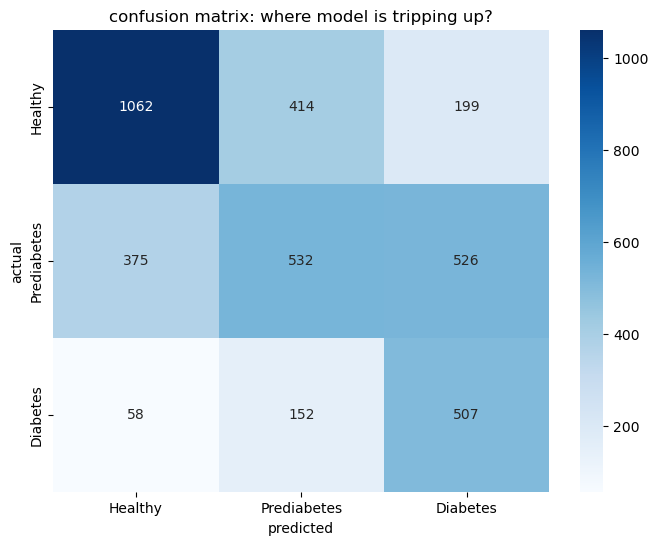

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Healthy", "Prediabetes", "Diabetes"],
    yticklabels=["Healthy", "Prediabetes", "Diabetes"],
)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("confusion matrix: where model is tripping up?")
plt.show()

I will engineer new features to see if it will help model perform any better. I thought catboost is good at fiding interaction between features already

In [ ]:
X["waist_bmi_ratio"] = X["waist_circumference"] / (X["bmi"] + 1e-5)
X["age_bmi_interaction"] = X["age"] * X["bmi"]
X["is_at_risk_age"] = (X["age"] > 45).astype(int)

'is_at_risk_age' should be category not integer but since it is basically 0 and 1, the models will be able to handle it well without me tagging it as category. I don't want to rewrite the code for the models setup again just for one feature

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15300 entries, 5095 to 24238
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   gender               15300 non-null  category
 1   age                  15300 non-null  float64 
 2   bmi                  15300 non-null  float64 
 3   race_ethnicity       15300 non-null  category
 4   waist_circumference  15300 non-null  float64 
 5   is_pregnant          15300 non-null  category
 6   family_history       15300 non-null  category
 7   waist_bmi_ratio      15300 non-null  float64 
 8   age_bmi_interaction  15300 non-null  float64 
 9   is_at_risk_age       15300 non-null  int32   
dtypes: category(4), float64(5), int32(1)
memory usage: 837.2 KB


In [ ]:
reporter_engineered = JupyterNotebookReporter(
    overwrite=True,
    metric_columns=[
        "f2_score",
        "recall_diabetes",
        "recall_prediabetes",
        "recall_healthy",
        "training_iteration",
        "time_total_s",
    ],
)

In [ ]:
tuner_engineered = tune.Tuner(
    train_evaluate_model,
    param_space=search_space,
    tune_config=tune.TuneConfig(
        metric="f2_score",
        mode="max",
        num_samples=15,
        trial_dirname_creator=reduce_ray_name,
    ),
    run_config=ray.air.RunConfig(
        name="tree_model_shootout",
        storage_path=ray_storage_path,
        callbacks=[mlflow_callback],
        progress_reporter=reporter_engineered,
    ),
)

c:\Users\User\anaconda3\envs\noteenv\Lib\site-packages\ray\tune\impl\tuner_internal.py:144: RayDeprecationWarning: The `RunConfig` class should be imported from `ray.tune` when passing it to the Tuner. Please update your imports. See this issue for more context and migration options: https://github.com/ray-project/ray/issues/49454. Disable these warnings by setting the environment variable: RAY_TRAIN_ENABLE_V2_MIGRATION_WARNINGS=0
  _log_deprecation_warning(


In [ ]:
results_engineered = tuner_engineered.fit()

2026-03-21 16:44:00,581	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949


(train_evaluate_model pid=30900) [LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001083 seconds.
(train_evaluate_model pid=30900) You can set `force_row_wise=true` to remove the overhead.
(train_evaluate_model pid=30900) And if memory is not enough, you can set `force_col_wise=true`.
(train_evaluate_model pid=30900) [LightGBM] [Info] Total Bins 1101
(train_evaluate_model pid=30900) [LightGBM] [Info] Number of data points in the train set: 15300, number of used features: 10
(train_evaluate_model pid=30900) [LightGBM] [Info] Start training from score -1.098612
(train_evaluate_model pid=30900) [LightGBM] [Info] Start training from score -1.098612
(train_evaluate_model pid=30900) [LightGBM] [Info] Start training from score -1.098612


2026-03-21 16:44:24,136	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'config/max_depth': <ray.tune.search.sample.Integer object at 0x0000017C8D8FF1D0>, 'config/learning_rate': <ray.tune.search.sample.Float object at 0x0000017C8D9AF190>, 'config/n_estimators': <ray.tune.search.sample.Categorical object at 0x0000017C8D86F2D0>}
2026-03-21 16:44:26,230	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'config/max_depth': <ray.tune.search.sample.Integer object at 0x0000017C8D951010>, 'config/learning_rate': <ray.tune.search.sample.Float object at 0x0000017C8D9E55D0>, 'config/n_estimators': <ray.tune.search.sample.Categorical object at 0x0000017C8D9E5350>}
2026-03-21 16:44:27,059	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'config/depth': <ray.tune.search.sample.Integer object at 0x0000017C8DAAC810>, 'config/learning_rate': <ra

(train_evaluate_model pid=19628) [LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000996 seconds.
(train_evaluate_model pid=19628) You can set `force_row_wise=true` to remove the overhead.
(train_evaluate_model pid=19628) And if memory is not enough, you can set `force_col_wise=true`.
(train_evaluate_model pid=19628) [LightGBM] [Info] Total Bins 1101
(train_evaluate_model pid=19628) [LightGBM] [Info] Number of data points in the train set: 15300, number of used features: 10
(train_evaluate_model pid=19628) [LightGBM] [Info] Start training from score -1.098612 [repeated 3x across cluster]


2026-03-21 16:44:57,488	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'config/max_depth': <ray.tune.search.sample.Integer object at 0x0000017C8DA7C1D0>, 'config/learning_rate': <ray.tune.search.sample.Float object at 0x0000017C8DA7E010>, 'config/n_estimators': <ray.tune.search.sample.Categorical object at 0x0000017C8DA7E810>}
2026-03-21 16:45:04,383	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'config/max_depth': <ray.tune.search.sample.Integer object at 0x0000017C8DA7E710>, 'config/n_estimators': <ray.tune.search.sample.Categorical object at 0x0000017C8DA7C390>}


(train_evaluate_model pid=4588) [LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001216 seconds.
(train_evaluate_model pid=4588) You can set `force_row_wise=true` to remove the overhead.
(train_evaluate_model pid=4588) And if memory is not enough, you can set `force_col_wise=true`.
(train_evaluate_model pid=4588) [LightGBM] [Info] Total Bins 1101
(train_evaluate_model pid=4588) [LightGBM] [Info] Number of data points in the train set: 15300, number of used features: 10
(train_evaluate_model pid=4588) [LightGBM] [Info] Start training from score -1.098612 [repeated 3x across cluster]


2026-03-21 16:45:08,835	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'config/max_depth': <ray.tune.search.sample.Integer object at 0x0000017C8DAACDD0>, 'config/n_estimators': <ray.tune.search.sample.Categorical object at 0x0000017C8DAAD710>}
2026-03-21 16:45:11,551	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'config/max_depth': <ray.tune.search.sample.Integer object at 0x0000017C8DA5D790>, 'config/n_estimators': <ray.tune.search.sample.Categorical object at 0x0000017C8DA5FCD0>}
2026-03-21 16:45:13,244	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'config/num_leaves': <ray.tune.search.sample.Integer object at 0x0000017C8DA9DD50>, 'config/learning_rate': <ray.tune.search.sample.Float object at 0x0000017C8DA5CF90>, 'config/n_estimators': <ray.tune.search.sample.Categorical object at 0x0000017C8DA5F090>}
2026-03-21 16:45:

In [ ]:
best_result = results_engineered.get_best_result(metric="f2_score", mode="max")
best_config = best_result.config["config"]
model_name = best_config["model_name"]
print(f"best model: {model_name}")
print(f"best model: {best_result}")

best model: XGBoost
best model: Result(
  metrics={'f2_score': 0.5548322011446634, 'recall_diabetes': 0.697350069735007, 'recall_prediabetes': 0.377529658060014, 'recall_healthy': 0.644179104477612},
  path='c:/Users/User/DiaWatch/backend/ray_results/tree_model_shootout/XGBoost_c7d31_00002',
  filesystem='local',
  checkpoint=None
)


In [ ]:
def apply_custom_thresholds(y_proba, t_prediabetes=0.35, t_diabetes=0.30):
    """
    y_proba shape: (n_samples, 3)
    Index 0: Healthy, Index 1: Prediabetes, Index 2: Diabetes
    """
    y_pred = np.zeros(y_proba.shape[0], dtype=int)

    diabetes_mask = y_proba[:, 2] >= t_diabetes

    prediabetes_mask = (y_proba[:, 1] >= t_prediabetes) & ~diabetes_mask

    y_pred[diabetes_mask] = 2
    y_pred[prediabetes_mask] = 1

    return y_pred

In [ ]:
def custom_macro_recall(y_true, y_proba):
    y_pred = apply_custom_thresholds(y_proba, t_prediabetes=0.35, t_diabetes=0.30)
    return recall_score(y_true, y_pred, average="macro")

In [ ]:
threshold_scorer = make_scorer(custom_macro_recall, response_method="predict_proba")
cv_scores = cross_val_score(
    final_model, X_train, y_train, cv=5, scoring=threshold_scorer
)
print(f"Custom CV Recall (macro): {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

Custom CV Recall (macro): 0.559 (+/- 0.007)


In [ ]:
def evaluate_thresholds(y_true, y_probs, t_pre, t_dia):
    preds = np.zeros(len(y_probs))
    preds[y_probs[:, 2] >= t_dia] = 2
    preds[(y_probs[:, 1] >= t_pre) & (y_probs[:, 2] < t_dia)] = 1
    return recall_score(y_true, preds, average="macro")

In [ ]:
y_train_proba = cross_val_predict(
    final_model, X_train, y_train, cv=5, method="predict_proba"
)

best_recall = 0
best_thresholds = (0.5, 0.5)

for t_pre in np.linspace(0.1, 0.4, 15):
    for t_dia in np.linspace(0.1, 0.4, 15):
        score = evaluate_thresholds(y_train, y_train_proba, t_pre, t_dia)
        if score > best_recall:
            best_recall = score
            best_thresholds = (t_pre, t_dia)

print(
    f" thresholds: Prediabetes={best_thresholds[0]:.2f}, Diabetes={best_thresholds[1]:.2f}"
)
y_test_proba = final_model.predict_proba(X_test)
final_test_preds = apply_custom_thresholds(
    y_test_proba, t_prediabetes=best_thresholds[0], t_diabetes=best_thresholds[1]
)

print(classification_report(y_test, final_test_preds))

Optimal Thresholds (Found via CV): Prediabetes@0.40, Diabetes@0.34
              precision    recall  f1-score   support

           0       0.71      0.60      0.65      1675
           1       0.47      0.31      0.37      1433
           2       0.38      0.78      0.51       717

    accuracy                           0.52      3825
   macro avg       0.52      0.56      0.51      3825
weighted avg       0.56      0.52      0.52      3825



In [ ]:
print(recall_score(y_test, final_test_preds, average=None))

[0.59880597 0.30565248 0.78242678]


In [ ]:
print(recall_score(y_test, final_test_preds, average="macro"))

0.5622950752374128


I am trading a bit of overall balance for more patient safety"

In [ ]:
ray.shutdown()